<a href="https://colab.research.google.com/github/HarshYadav115/Deep-Learnin/blob/main/EXP_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

Celsius | Predicted (F) | Actual (F)
-------------------------------------
 -20.00 |          -4.06 |      -4.00
   0.00 |          31.95 |      32.00
  25.00 |          76.96 |      77.00
  50.00 |         121.97 |     122.00
 100.00 |         211.99 |     212.00


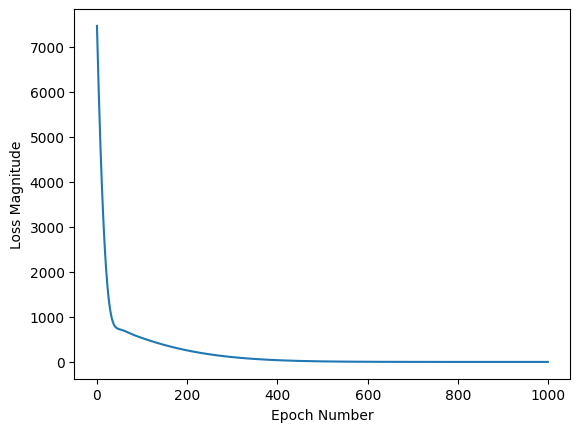

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare data
celsius_q = np.array([-40, -10, 0, 8, 15, 22, 38], dtype=float)
fahrenheit_a = celsius_q * 1.8 + 32

# 2. Define model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1, input_shape=[1])
])

# 3. Compile model
model.compile(loss='mean_squared_error',
              optimizer=tf.keras.optimizers.Adam(0.1))

# 4. Train model
history = model.fit(celsius_q, fahrenheit_a, epochs=1000, verbose=0)

# 5. Predictions for multiple values
test_celsius = np.array([-20, 0, 25, 50, 100], dtype=float)

predicted_f = model.predict(test_celsius)

print("\nCelsius | Predicted (F) | Actual (F)")
print("-------------------------------------")

for i in range(len(test_celsius)):
    c = test_celsius[i]
    pred = predicted_f[i][0]
    actual = c * 1.8 + 32
    print(f"{c:7.2f} | {pred:14.2f} | {actual:10.2f}")

# 6. Plot loss
plt.xlabel('Epoch Number')
plt.ylabel("Loss Magnitude")
plt.plot(history.history['loss'])
plt.show()